In [ ]:
# ============================================================
# PROYECTO: Analisis de CHURN de Clientes — Telecom Industry
# ETAPA: Carga y Exploración Inicial
# ============================================================


import pandas as pd          # Manipulación de datos
import matplotlib.pyplot as plt  # Visualización base
import seaborn as sns        # Visualización estadística

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [4]:
df = pd.read_csv("../data/telco_churn_raw.csv")
print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")

Dataset cargado: 7043 filas x 21 columnas


In [ ]:
print("=== PRIMERAS 5 FILAS ===")
df.head()

=== PRIMERAS 5 FILAS ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("=== INFORMACIÓN GENERAL ===")
df.info()

# ¿Qué nos dice .info()?
# - Nombre de cada columna
# - Cuántos valores NO nulos tiene
# - El tipo de dato de cada columna (int, float, object)
# - Uso de memoria del dataset

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

In [ ]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe()

# ¿Qué nos dice .describe()?
# count  → cuántos valores no nulos hay
# mean   → promedio
# std    → desviación estándar (dispersión)
# min    → valor mínimo
# 25%    → primer cuartil (el 25% de datos está por debajo)
# 50%    → mediana
# 75%    → tercer cuartil
# max    → valor máximo

=== ESTADÍSTICAS DESCRIPTIVAS ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
print("=== DISTRIBUCIÓN DE CHURN ===")
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print(churn_counts)
print("\nEn porcentaje:")
print(churn_pct.round(2))

=== DISTRIBUCIÓN DE CHURN ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

En porcentaje:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


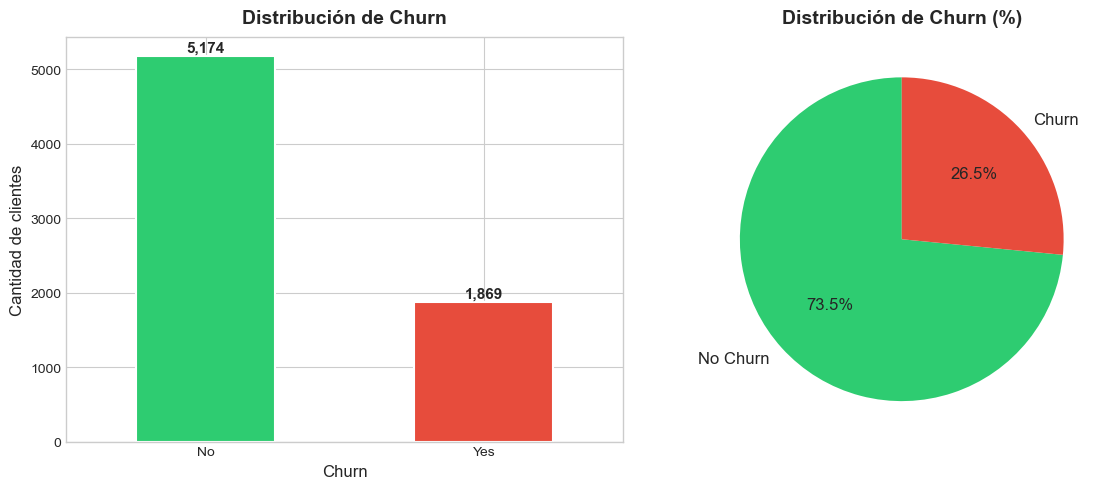

In [ ]:
# --- Visualización de la distribución de Churn ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
churn_counts.plot( kind="bar", ax=ax1, color=["#2ecc71", "#e74c3c"], edgecolor= "white", linewidth=1.5)
ax1.set_title("Distribución de Churn", fontsize=14, fontweight="bold", pad=10)
ax1.set_xlabel("Churn", fontsize=12)
ax1.set_ylabel("Cantidad de clientes", fontsize=12)
ax1.tick_params(axis="x", rotation = 0)

offset = df["Churn"].value_counts().max() * 0.005

for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height() + offset), ha="center", va="bottom", fontsize=11, fontweight="bold")

# Gráfico de torta
colors = ["#2ecc71", "#e74c3c"]
ax2.pie(churn_counts, labels=["No Churn", "Churn"], autopct="%1.1f%%", colors=colors, startangle=90, textprops={"fontsize": 12})
ax2.set_title("Distribución de Churn (%)", fontsize=14, fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig('../visuals/01_distribucion_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Resumen del Dataset y Diagnóstico de Negocio

---

### **1. Estructura del Dataset**
* **Dimensiones:** 7.043 registros × 21 variables.
* **Segmentación de Atributos:**
    * **Demográficos:** `Género`, `SeniorCitizen`, `Partner`, `Dependents`.
    * **Servicios:** `Phone`, `Internet`, `Online Security`, `Backup`, etc.
    * **Contractuales:** `Tipo de contrato (mensual/anual)`, `método de pago`, `PaperlessBilling`.
    * **Métricas Financieras:** `Tenure` (antigüedad), `MonthlyCharges`, `TotalCharges`.
    * **Variable Target:** `Churn` (Indicador binario de abandono).

### **2. Hallazgo Crítico: Análisis de Churn**
* **Tasa de Abandono:** **26.5%**
* **Volumen de Clientes:** ~1.869 usuarios perdidos en el período analizado.
